In [8]:
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from scipy.ndimage import uniform_filter1d

In [ ]:
df = pd.read_csv("Copper_Gold_Drillholes.csv", sep=",")
 
COL_X    = "X"       # columna de coordenada X
COL_Y    = "Y"       # columna de coordenada Y
COL_Z    = "Z"       # columna de coordenada Z
PROPERTY = "Cu"      # variable a analizar
 
CELL_MIN  =   5      # tamaño mínimo de celda a evaluar (m)
CELL_MAX  = 200      # tamaño máximo de celda a evaluar (m)
CELL_STEP =   5      # paso entre evaluaciones (m)
 
# Relación entre tamaño de celda en Z y en XY.
# Ajusta según el intervalo de composición de tus sondajes.
Z_XY_RATIO = 0.25
 
N_ITER = 100   # iteraciones del método de celdas por tamaño
               # (aumentar a 200–300 para curvas más estables, más lento el procesamiento)
SEED   =  42   # semilla para reproducibilidad
 
# Ventana de suavizado para eliminar ruido estocástico (número impar, ≥ 3)
# Aumentar si la curva tiene mucho ruido (ej. pocos datos o pocas iteraciones)
SMOOTH_WINDOW = 5
 

In [ ]:
# Preparación de los datos
random.seed(SEED)
df.columns = [c.strip().lstrip("\ufeff") for c in df.columns]
df[[COL_X, COL_Y, COL_Z, PROPERTY]] = df[
    [COL_X, COL_Y, COL_Z, PROPERTY]
].apply(pd.to_numeric, errors="coerce")
 
x          = df[COL_X].values
y          = df[COL_Y].values
z          = df[COL_Z].values
v          = df[PROPERTY].values
arith_mean = np.nanmean(v)
n_samples  = int((~np.isnan(v)).sum())
 
 
# Función de media declusterizada para el tamaño de celda antes ingresado
def decluster_mean(x, y, z, values, xcell, ycell, zcell):
    """Media declusteada por método de celdas (Deutsch & Journel 1998)."""
    mask = ~np.isnan(values)
    xm, ym, zm, vm = x[mask], y[mask], z[mask], values[mask]
    if len(vm) == 0:
        return np.nan
    xo, yo, zo = xm.min() - 0.01, ym.min() - 0.01, zm.min() - 0.01
    all_w = []
    for _ in range(N_ITER):
        xori = xo - random.uniform(0, 1) * xcell
        yori = yo - random.uniform(0, 1) * ycell
        zori = zo - random.uniform(0, 1) * zcell
        xnc  = int((xm.max() - xori) / xcell) + 1
        ync  = int((ym.max() - yori) / ycell) + 1
        xi   = (((xm - xori) / xcell) + 1).astype(int)
        yi   = (((ym - yori) / ycell) + 1).astype(int)
        zi   = (((zm - zori) / zcell) + 1).astype(int)
        ic   = xi + (yi - 1) * xnc + (zi - 1) * xnc * ync - 1
        cnt  = np.bincount(ic)
        all_w.append([1.0 / cnt[ic[k]] for k in range(len(xm))])
    w = np.average(all_w, axis=0)
    return np.nansum(w * vm) / np.nansum(w)
 
# Calculamos la curva de media declusterizada para cada tamaño de celda
cell_sizes = list(range(CELL_MIN, CELL_MAX + 1, CELL_STEP))
means      = []
 
print(f"Evaluando {len(cell_sizes)} tamaños de celda ({CELL_MIN}–{CELL_MAX} m)...")
for cs in cell_sizes:
    m = decluster_mean(x, y, z, v, cs, cs, max(cs * Z_XY_RATIO, 1.0))
    means.append(m)
    print(f"  {cs:4d} m → {m:.5f}", end="\r")
print(" " * 40, end="\r")

Evaluando 40 tamaños de celda (5–200 m)...


In [12]:
""" Detectamos el tamaño óptimo del codo. 
El codo es el punto de MÁXIMA caída de la media declusterizada, 
es decir, el máximo de la derivada primera (en valor absoluto).
Se suaviza con una ventana de 3 puntos para reducir el ruido
estocástico propio del método de celdas. """
# Detectamos la maxima de la distancia perpendicular a la cuerda (método del codo)
arr      = np.array(means)
cells    = np.array(cell_sizes)
 
# Suavizamos para eliminar ruido estocástico
smoothed = uniform_filter1d(arr, size=SMOOTH_WINDOW)
 
""" Método de la cuerda: normalizamos ambos ejes a [0, 1]
y calculamos la distancia perpendicular de cada punto
a la recta que une el primer y el último punto de la curva. """
xn = (cells    - cells[0])    / (cells[-1]    - cells[0])
yn = (smoothed - smoothed[0]) / (smoothed[-1] - smoothed[0])
 
# Recta de inicio a fin en espacio normalizado: pasa por (0,0) y (1,1)
# Distancia de punto (xn_i, yn_i) a esa recta = |xn_i - yn_i| / sqrt(2)
dist     = np.abs(xn - yn) / np.sqrt(2)
opt_idx  = int(np.argmax(dist))
optimal  = cell_sizes[opt_idx]
opt_mean = means[opt_idx]
opt_z    = max(optimal * Z_XY_RATIO, 1.0)
 
print(f"Codo detectado: {optimal} m  |  media declusterizada = {opt_mean:.4f}")
print(f"Media aritmética:              {arith_mean:.4f}")
print(f"Parámetros recomendados para declustering:")
print(f"  xcellsize  = {optimal}")
print(f"  ycellsize  = {optimal}")
print(f"  zcellsize  = {opt_z:.1f}")

Codo detectado: 90 m  |  media declusterizada = 0.9048
Media aritmética:              1.0541
Parámetros recomendados para declustering:
  xcellsize  = 90
  ycellsize  = 90
  zcellsize  = 22.5


C:\Users\Felipe\AppData\Local\Temp\ipykernel_27360\470898664.py:77: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


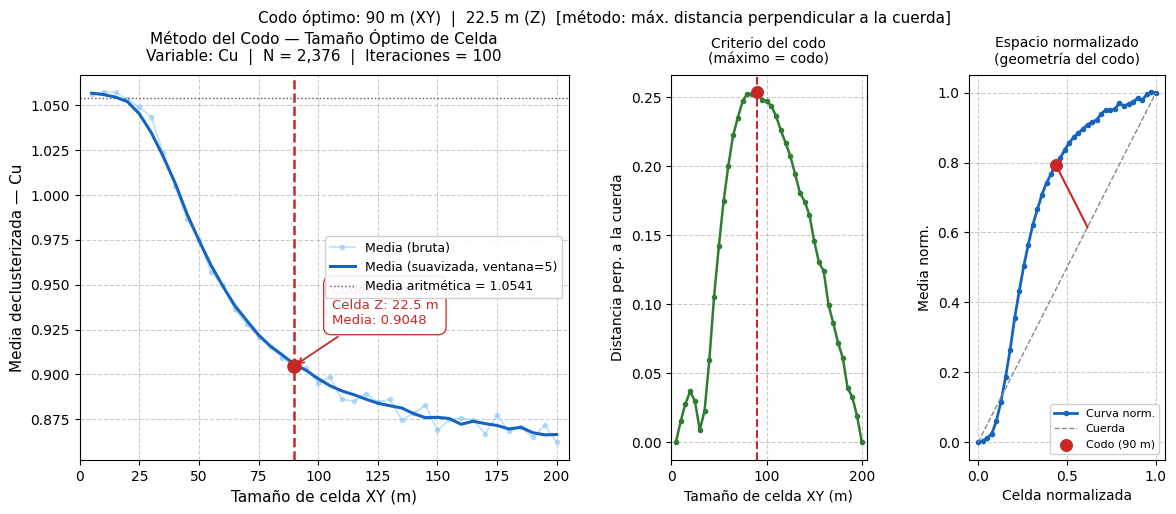

Gráfico guardado → elbow_declustering.png


In [ ]:
# Graficamos
fig = plt.figure(figsize=(14, 5))
gs  = gridspec.GridSpec(1, 3, width_ratios=[3, 1.2, 1.2], wspace=0.35)
 
# Panel izquierdo: curva de medias declusterizadas
ax = fig.add_subplot(gs[0])
 
ax.plot(cell_sizes, means, color="#90CAF9", linewidth=1.2,
        marker="o", markersize=3, zorder=2, alpha=0.6, label="Media (bruta)")
ax.plot(cell_sizes, smoothed, color="#1565C0", linewidth=2.2,
        zorder=3, label=f"Media (suavizada, ventana={SMOOTH_WINDOW})")
 
ax.axhline(arith_mean, color="#555", linewidth=1, linestyle=":",
           label=f"Media aritmética = {arith_mean:.4f}")
ax.axvline(optimal, color="#C62828", linewidth=1.8, linestyle="--", zorder=4)
ax.scatter([optimal], [opt_mean], color="#C62828", s=90, zorder=5)
 
ax.annotate(
    f"Codo: {optimal} m\nCelda Z: {opt_z:.1f} m\nMedia: {opt_mean:.4f}",
    xy=(optimal, opt_mean),
    xytext=(optimal + (CELL_MAX - CELL_MIN) * 0.08,
            opt_mean + (arr.max() - arr.min()) * 0.12),
    fontsize=9.5, color="#C62828",
    bbox=dict(boxstyle="round,pad=0.60", fc="white", ec="#C62828", alpha=0.92),
    arrowprops=dict(arrowstyle="->", color="#C62828", lw=1.3),
)
 
ax.set_xlabel("Tamaño de celda XY (m)", fontsize=11)
ax.set_ylabel(f"Media declusterizada — {PROPERTY}", fontsize=11)
ax.set_title(
    f"Método del Codo — Tamaño Óptimo de Celda\n"
    f"Variable: {PROPERTY}  |  N = {n_samples:,}  |  Iteraciones = {N_ITER}",
    fontsize=11, pad=10,
)
ax.grid(color="gray", linestyle="--", alpha=0.4)
ax.legend(fontsize=9, framealpha=0.9)
ax.set_xlim(CELL_MIN - CELL_STEP, CELL_MAX + CELL_STEP)
 
# Grafico central: distancia perpendicular a la cuerda
# El máximo de esta curva es el codo
ax2 = fig.add_subplot(gs[1])
ax2.plot(cell_sizes, dist, color="#2E7D32", linewidth=1.8,
         marker="o", markersize=3)
ax2.axvline(optimal, color="#C62828", linewidth=1.5, linestyle="--")
ax2.scatter([optimal], [dist[opt_idx]], color="#C62828", s=70, zorder=5)
ax2.set_xlabel("Tamaño de celda XY (m)", fontsize=10)
ax2.set_ylabel("Distancia perp. a la cuerda", fontsize=10)
ax2.set_title("Criterio del codo\n(máximo = codo)", fontsize=10, pad=8)
ax2.grid(color="gray", linestyle="--", alpha=0.4)
ax2.set_xlim(CELL_MIN - CELL_STEP, CELL_MAX + CELL_STEP)
 
# Grafico derecho: curva normalizada 
ax3 = fig.add_subplot(gs[2])
ax3.plot(xn, yn, color="#1565C0", linewidth=2, marker="o", markersize=3,
         label="Curva norm.")
ax3.plot([0, 1], [0, 1], color="#888", linewidth=1, linestyle="--",
         label="Cuerda")
# Dibujamos la distancia perpendicular del punto óptimo
xi, yi = xn[opt_idx], yn[opt_idx]
# Pie de la perpendicular en la recta y=x: punto_medio = ((xi+yi)/2, (xi+yi)/2)
xp, yp = (xi + yi) / 2, (xi + yi) / 2
ax3.plot([xi, xp], [yi, yp], color="#C62828", linewidth=1.5, linestyle="-")
ax3.scatter([xi], [yi], color="#C62828", s=70, zorder=5,
            label=f"Codo ({optimal} m)")
ax3.set_xlabel("Celda normalizada", fontsize=10)
ax3.set_ylabel("Media norm.", fontsize=10)
ax3.set_title("Espacio normalizado\n(geometría del codo)", fontsize=10, pad=8)
ax3.legend(fontsize=8, framealpha=0.9)
ax3.grid(color="gray", linestyle="--", alpha=0.4)
 
plt.suptitle(
    f"Codo óptimo: {optimal} m (XY)  |  {opt_z:.1f} m (Z)  "
    f"[método: máx. distancia perpendicular a la cuerda]",
    fontsize=11, fontweight="medium", y=1.01,
)
 
plt.tight_layout()
plt.savefig("elbow_declustering.png", dpi=150, bbox_inches="tight")
plt.show()
print("Gráfico guardado → elbow_declustering.png")